# NumPy Lab: Numerical Python
---

**Introduction to data science and visualization — Politecnico di Torino**  

The objective of this notebook is to learn the **NumPy** library ([official documentation](https://numpy.org/doc/stable/reference/index.html)). NumPy provides efficient storage and operations on dense data buffers and is the foundation of virtually every data-science library in Python (scikit-learn, SciPy, Pandas, PyTorch, …).

> **⚠️ Rule for this lab:** Exploit NumPy and avoid explicit `for` loops and Python lists for **all** exercises.

**Duration:** ~90 min  
**Prerequisites:** Python basics

## Outline

- [1. Setup & Why NumPy?](#1)
- [2. Creating Arrays](#2)
- [3. Array Attributes & Data Types](#3)
- [4. Universal Functions (Ufuncs)](#4)
- [6. Broadcasting](#6)
- [7. Masking & Fancy Indexing](#7)
- [8. Mini softmax implementation](#8)
- [9. Min-Max Normalization with NumPy (Bonus Track)](#9)

First, run the following cell to import the required libraries.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time

print("NumPy version:", np.__version__)

NumPy version: 2.4.4


Run the following cell containing helper plotting functions used later in the lab.

In [3]:
def plot_distributions(my_list, names):
    fig, ax = plt.subplots(1, len(my_list), figsize=(14, 6))
    fig.suptitle("Frequency Histograms", fontsize=20)
    for i, x in enumerate(my_list):
        ax[i].hist(x, 25)
        ax[i].axvline(x.mean(), color="k", linestyle="dashed", linewidth=2)
        ax[i].set_xlabel(names[i], fontsize=14)
        ax[i].set_ylabel("Frequency", fontsize=14)
    plt.tight_layout()
    plt.show()


def plot_2d_points(X, Y, norm_flag=False):
    fig, ax = plt.subplots(figsize=(10, 5))
    if norm_flag:
        ax.set_xlabel("Size of the house norm", fontsize=14)
    else:
        ax.set_xlabel("Size of the house", fontsize=14)
    ax.set_ylabel("Price", fontsize=14)
    ax.scatter(X, Y)
    plt.show()


def plot_3d_points(X, Y, norm_flag=False):
    fig, ax = plt.subplots(figsize=(20, 10))
    ax = fig.add_subplot(projection="3d")
    if norm_flag:
        ax.set_xlabel("Size of the house norm", fontsize=14)
        ax.set_ylabel("Number of rooms norm", fontsize=14)
    else:
        ax.set_xlabel("Size of the house", fontsize=14)
        ax.set_ylabel("Number of rooms", fontsize=14)
    ax.set_zlabel("Price", fontsize=14)
    ax.scatter(X[:, 0], X[:, 1], Y)
    plt.tight_layout()
    plt.show()

<a id='1'></a>
## 1. Setup & Why NumPy?

NumPy is the backbone of scientific computing in Python. Libraries like scikit-learn, SciPy, Pandas, and PyTorch all build on top of NumPy arrays. In this lab you will learn to think in *vectorized operations* — replacing slow Python loops with fast array operations.

**Why is NumPy fast?**
- **Fixed-type arrays** — no per-element overhead (unlike Python lists which store pointers to separate PyObjects)
- **Contiguous memory** — faster cache utilization and indexing
- **Compiled C code** — operations are executed in optimized compiled routines

### Speed comparison: Python lists vs NumPy

Let's add two random 1000×1000 matrices — first with nested loops, then with NumPy.

In [4]:
n = 1000

# --- Pure Python ---
from random import random as py_random

A_list = [[py_random() for _ in range(n)] for _ in range(n)]
B_list = [[py_random() for _ in range(n)] for _ in range(n)]

t0 = time.time()
C_list = [[A_list[i][j] + B_list[i][j] for j in range(n)] for i in range(n)]
t_python = time.time() - t0

# --- NumPy ---
A_np = np.random.random((n, n))
B_np = np.random.random((n, n))

t0 = time.time()
C_np = A_np + B_np
t_numpy = time.time() - t0

print(f"Python lists : {t_python:.4f}s")
print(f"NumPy        : {t_numpy:.6f}s")
print(f"Speedup      : {t_python / t_numpy:.0f}x")

Python lists : 0.0626s
NumPy        : 0.002579s
Speedup      : 24x


<a id='2'></a>
## 2. Creating Arrays

### From Python lists

In [5]:
# 1-D array (vector)
v = np.array([1, 2, 3])
print("v =", v)

# 2-D array (matrix)
M = np.array([[1, 2, 3], [4, 5, 6]])
print("M =\n", M)

# 3-D array
T = np.array([[[1, 2, 3], [4, 5, 6]], [[7, 8, 9], [10, 11, 12]]])
print("T shape:", T.shape)

v = [1 2 3]
M =
 [[1 2 3]
 [4 5 6]]
T shape: (2, 2, 3)


### Factory functions

In [6]:
print("zeros:   \n", np.zeros((2, 3)))
print("ones:    \n", np.ones((2, 3)))
print("full:    \n", np.full((2, 3), 3.14))
print("eye:     \n", np.eye(3))  # identity matrix

# Sequences
print("arange:   ", np.arange(0, 10, 2))  # start, stop(excl), step
print("linspace: ", np.linspace(0, 1, 5))  # start, stop(incl), num

# Random
print("uniform:  \n", np.random.random((2, 3)))
print("normal:   \n", np.random.normal(0, 1, (2, 3)))
print("randint:  \n", np.random.randint(0, 10, (2, 3)))

zeros:   
 [[0. 0. 0.]
 [0. 0. 0.]]
ones:    
 [[1. 1. 1.]
 [1. 1. 1.]]
full:    
 [[3.14 3.14 3.14]
 [3.14 3.14 3.14]]
eye:     
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
arange:    [0 2 4 6 8]
linspace:  [0.   0.25 0.5  0.75 1.  ]
uniform:  
 [[0.65169089 0.43411444 0.8292882 ]
 [0.16215584 0.42773426 0.6873651 ]]
normal:   
 [[ 0.5085276   0.42018278 -0.77678845]
 [ 1.1884293   0.27433454 -1.45133347]]
randint:  
 [[2 0 3]
 [1 3 9]]


<a id='3'></a>
## 3. Array Attributes & Data Types

In [7]:
x = np.array([[2, 3, 4], [5, 6, 7]])

print("ndim : ", x.ndim)  # number of dimensions (axes)
print("shape: ", x.shape)  # tuple: size along each axis
print("size : ", x.size)  # total number of elements
print("dtype: ", x.dtype)  # element data type

ndim :  2
shape:  (2, 3)
size :  6
dtype:  int64


### Specifying data types

In [8]:
# Explicit dtype
a = np.array([1, 2, 3], dtype=np.float32)
print("dtype:", a.dtype)

# Common types: int8, int16, int32, int64
#               uint8 ... uint64
#               float16, float32, float64
#               bool

dtype: float32


### Column vector vs row vector — important distinction!

In [9]:
row = np.array([0.1, 0.2, 0.3])  # shape (3,)
col = np.array([[0.1], [0.2], [0.3]])  # shape (3, 1) — 2-D!
print("row shape:", row.shape)
print("col shape:", col.shape)

row shape: (3,)
col shape: (3, 1)


> **⚠️ Common pitfall:** A 1-D array with shape `(3,)` is **not** the same as a column vector with shape `(3, 1)`. This matters for broadcasting and matrix operations. Use `.reshape(-1, 1)` or `[:, np.newaxis]` to convert.

<a id='4'></a>
## 4. Universal Functions (Ufuncs)

Ufuncs are NumPy's vectorized wrappers for element-wise operations — they replace Python loops and run at compiled-code speed.

### Binary ufuncs (two arrays → one array)

In [10]:
x = np.array([[1, 2], [3, 4]])
y = np.array([[10, 20], [30, 40]])

print("x + y =\n", x + y)
print("x * y =\n", x * y)  # element-wise, NOT matrix multiplication!
print("x ** 2 =\n", x**2)
print("x % 2 =\n", x % 2)  # modulus
print("x // 3 =\n", x // 3)  # floor division

x + y =
 [[11 22]
 [33 44]]
x * y =
 [[ 10  40]
 [ 90 160]]
x ** 2 =
 [[ 1  4]
 [ 9 16]]
x % 2 =
 [[1 0]
 [1 0]]
x // 3 =
 [[0 0]
 [1 1]]


### Exercise 4.1
Add the value 5 to **each element** of the Numpy array `my_arr`.

#### Expected output
```
[[ 6  7  8]
 [ 9 10 11]
 [12 13 14]]
```

In [11]:
my_arr = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])

#### START CODE HERE ####
my_arr = my_arr+5
#### END CODE HERE ####

print(my_arr)

[[ 6  7  8]
 [ 9 10 11]
 [12 13 14]]


### Exercise 4.2
Perform the element-wise **logarithm** of the Numpy array `my_arr`.

#### Expected output
```
[[0.         0.69314718 1.09861229]
 [1.38629436 1.60943791 1.79175947]
 [1.94591015 2.07944154 2.19722458]]
```

In [12]:
my_arr = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])

#### START CODE HERE ####
my_arr = np.log(my_arr)
#### END CODE HERE ####

print(my_arr)

[[0.         0.69314718 1.09861229]
 [1.38629436 1.60943791 1.79175947]
 [1.94591015 2.07944154 2.19722458]]


### Unary ufuncs

In [13]:
x = np.array([-2, -1, 0, 1, 2])

print("abs:  ", np.abs(x))
print("exp:  ", np.exp(x))
print("log:  ", np.log(np.array([1, np.e, np.e**2])))
print("sin:  ", np.sin(np.array([0, np.pi / 2, np.pi])))

abs:   [2 1 0 1 2]
exp:   [0.13533528 0.36787944 1.         2.71828183 7.3890561 ]
log:   [0. 1. 2.]
sin:   [0.0000000e+00 1.0000000e+00 1.2246468e-16]


> **Key rule:** Ufuncs **do not modify** the original array — they return a new one. Assign the result: `y = np.exp(x)`.

### Algebraic operations: the `@` operator

In [14]:
# Inner (dot) product of two vectors
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])
print("a @ b =", a @ b)  # 1*4 + 2*5 + 3*6 = 32

# Matrix × vector
W = np.array([[1, 2], [3, 4]])
v = np.array([5, 6])
print("W @ v =", W @ v)  # [1*5+2*6, 3*5+4*6] = [17, 39]

# Matrix × matrix
X = np.array([[1, 0], [0, 1]])
print("W @ X =\n", W @ X)  # identity keeps W unchanged

a @ b = 32
W @ v = [17 39]
W @ X =
 [[1 2]
 [3 4]]


### Exercise 4.3 — Linear transformation
A common operation in machine learning is computing `y = Wx + b` where `W` is a weight matrix, `x` is an input vector, and `b` is a bias vector.

1. Create `W` as a 3×4 matrix of random values (normal distribution, mean 0, std 0.1).
2. Create `x` as a 1-D array of 4 ones.
3. Create `b` as a 1-D array of 3 zeros.
4. Compute `y = W @ x + b` and print the result and its shape.

In [15]:
#### START CODE HERE ####
mean = 0
std = 0.1
W = np.random.normal(mean, std, (3,4))
x = np.ones((4), dtype=np.int16)
b = np.zeros((3), dtype=np.int16)

y = W @ x + b
print(f"y = {y}")
print(f"y shape: {y.shape}")
#### END CODE HERE ####

y = [-0.09405901 -0.16866308  0.18733082]
y shape: (3,)


<a id='5'></a>
## 5. Aggregation Functions

### Exercise 5.1
Compute the **mean** in `arr_mean`, the **standard deviation** in `arr_std`, the **sum** in `arr_sum`, the **max** value in `arr_max`, and the **index of the max** value in `arr_max_idx` of the array `my_arr`.

#### Expected output
```
mean: 5.0
standard deviation: 2.581988897471611
sum: 45
max value: 9
index of the max value: 8
```

In [16]:
my_arr = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])

#### START CODE HERE ####
arr_mean = my_arr.mean()
arr_std = my_arr.std()
arr_sum = my_arr.sum()
arr_max = my_arr.max()
arr_max_idx = my_arr.argmax()
#### END CODE HERE ####

print(f"mean: {arr_mean}")
print(f"standard deviation: {arr_std}")
print(f"sum: {arr_sum}")
print(f"max value: {arr_max}")
print(f"index of the max value: {arr_max_idx}")

mean: 5.0
standard deviation: 2.581988897471611
sum: 45
max value: 9
index of the max value: 8


### Aggregation along an axis

The `axis` parameter specifies which dimension gets "collapsed". The output loses that dimension.

In [17]:
x = np.array([[1, 7], [2, 4]])

# axis=0 → collapse rows → one value per column
print("sum axis=0:", x.sum(axis=0))  # [3, 11]

# axis=1 → collapse columns → one value per row
print("sum axis=1:", x.sum(axis=1))  # [8, 6]

# argmax along axis 0: index of max in each column
print("argmax axis=0:", x.argmax(axis=0))  # [1, 0]

sum axis=0: [ 3 11]
sum axis=1: [8 6]
argmax axis=0: [1 0]


### Exercise 5.2
Compute the **mean** along the **rows axis** in `arr_mean_rows` of the array `my_arr`.

<details>
<summary><b>Hints</b></summary>
<ul><li>You should specify the axis parameter in <code>np.mean()</code></li></ul>
</details>

#### Expected output
```
mean of the rows: [2. 5. 8.]
```

In [18]:
my_arr = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
print(my_arr)

#### START CODE HERE ####
arr_mean_rows = my_arr.mean(axis=1)
#### END CODE HERE ####

print(f"\nmean of the rows: {arr_mean_rows}")

[[1 2 3]
 [4 5 6]
 [7 8 9]]

mean of the rows: [2. 5. 8.]


### Exercise 5.3
Compute the **mean** along the **columns axis** in `arr_mean_cols` of the array `my_arr`.

#### Expected output
```
mean of the columns: [4. 5. 6.]
```

In [19]:
my_arr = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
print(my_arr)

#### START CODE HERE ####
arr_mean_cols = my_arr.mean(axis=0)
#### END CODE HERE ####

print(f"\nmean of the columns: {arr_mean_cols}")

[[1 2 3]
 [4 5 6]
 [7 8 9]]

mean of the columns: [4. 5. 6.]


Note that both the mean along the rows axis and the mean along the columns axis return a **row vector**.

### Exercise 5.4
Using the matrix `scores` (rows = students, columns = exams):

1. Compute the average score of each student and store it in `student_means`.
2. Compute the average score for each exam and store it in `exam_means`.
3. Print both arrays.

In [20]:
scores = np.array(
    [[85, 92, 78, 90],
     [76, 88, 95, 82],
     [90, 74, 88, 95],
     [68, 82, 73, 89]]
)

#### START CODE HERE ####
students_means = scores.mean(axis=1)
exams_means = scores.mean(axis=0)
#### END CODE HERE ####

print(f"Student averages: {students_means}")
print(f"Exam averages: {exams_means}")


Student averages: [86.25 85.25 86.75 78.  ]
Exam averages: [79.75 84.   83.5  89.  ]


## 6. Broadcasting

Broadcasting allows NumPy to perform element-wise operations on arrays with **different shapes** by automatically "stretching" the smaller array to match the larger one without creating unnecessary copies in memory.

### The Three Rules of Broadcasting

To determine if two arrays are compatible, NumPy compares their dimensions starting from the **rightmost** (trailing) side:

> **Rule 1: Padding** > If the arrays have a different number of dimensions, the shape of the smaller one is padded with **leading 1s** on its left side.
>
> **Rule 2: Stretching** > If the shape differs along a dimension and one of those dimensions is **1**, that array is stretched (conceptually repeated) to match the size of the other array along that axis.
>
> **Rule 3: Failure** > If in any dimension the sizes are different and neither is 1, broadcasting **fails** and NumPy raises a `ValueError`.

---

### Logic Example
When adding a 1D array of shape `(3,)` to a 2D array of shape `(3, 3)`:

1.  **Align:** `(3, 3)` and `(3,)`
2.  **Rule 1:** The `(3,)` becomes `(1, 3)`.
3.  **Rule 2:** The `1` in `(1, 3)` is stretched to `3` to match the first dimension of the matrix.
4.  **Execute:** The operation proceeds element-wise.

### Examples

In [21]:
# a) Matrix + scalar
M = np.array([[1, 2], [3, 4]])
print(f"M shape: {M.shape}")
print("M + 10 =\n", M + 10)

# b) Matrix + row vector (broadcasts along axis 0)
row = np.array([10, 20])
print(f"\nM shape: {M.shape}, row vector shape: {row.shape}")
print("M + row =\n", M + row)

# c) Matrix + column vector (broadcasts along axis 1)
col = np.array([[100], [200]])
print(f"\nM shape: {M.shape}, column vector shape: {col.shape}")
print("M + col =\n", M + col)

# d) Row vector + column vector → outer sum!
x = np.array([1, 2, 3])
y = np.array([[10], [20], [30]])
print(f"\nRow vector x shape: {x.shape}, Column vector y shape: {y.shape}")
print("outer sum =\n", x + y)


M shape: (2, 2)
M + 10 =
 [[11 12]
 [13 14]]

M shape: (2, 2), row vector shape: (2,)
M + row =
 [[11 22]
 [13 24]]

M shape: (2, 2), column vector shape: (2, 1)
M + col =
 [[101 102]
 [203 204]]

Row vector x shape: (3,), Column vector y shape: (3, 1)
outer sum =
 [[11 12 13]
 [21 22 23]
 [31 32 33]]


### When broadcasting fails

In [22]:
# This will fail: shapes (3, 2) and (1, 3) → last dim 2 vs 3
A = np.ones((3, 2))
B = np.ones((1, 3))
try:
    C = A + B
except ValueError as e:
    print("Error:", e)

Error: operands could not be broadcast together with shapes (3,2) (1,3) 


### Exercise 6.1 — Normalize rows using broadcasting
A very common operation in data science: given a matrix, subtract each row's mean and divide by its standard deviation (z-score normalization).

```python
data = np.array([[100, 200, 300],
                 [4,   5,   6],
                 [50,  60,  70]], dtype=np.float64)
```

Compute `normalized = (data - row_means) / row_stds`. Verify: each row of `normalized` should have mean ≈ 0, std ≈ 1.

<details>
<summary><b>Hints</b></summary>
<ul>
<li>Use <code>data.mean(axis=1, keepdims=True)</code> to get a (3,1) shaped mean.</li>
<li>The <code>keepdims=True</code> parameter preserves the dimension so broadcasting works.</li>
</ul>
</details>

In [23]:
data = np.array([[100, 200, 300],
                 [4, 5, 6],
                 [50, 60, 70]], dtype=np.float64)

#### START CODE HERE ####
row_means = data.mean(axis=1).reshape(-1,1)
row_std = data.std(axis=1).reshape(-1,1)
normalized = (data - row_means) / row_std
#### END CODE HERE ####

print("Normalized:\n", normalized)
print("Row means (should be ~0):", normalized.mean(axis=1))
print("Row stds  (should be ~1):", normalized.std(axis=1))

Normalized:
 [[-1.22474487  0.          1.22474487]
 [-1.22474487  0.          1.22474487]
 [-1.22474487  0.          1.22474487]]
Row means (should be ~0): [0. 0. 0.]
Row stds  (should be ~1): [1. 1. 1.]


<a id='7'></a>
## 7. Masking & Fancy Indexing

### Boolean masking

In [24]:
x = np.array([1.2, 4.1, 1.5, 4.5, 3.0])

# Create a boolean mask
mask = x > 3
print("mask:", mask)

# Use mask to select elements → returns 1-D copy
print("x[mask]:", x[mask])

# Combining masks: use & (and), | (or), ~ (not)
mask2 = (x >= 1.5) & (x <= 4.1)
print("between 1.5 and 4.1:", x[mask2])

# Assign through mask
x[x > 4] = 0
print("after clipping:", x)

mask: [False  True False  True False]
x[mask]: [4.1 4.5]
between 1.5 and 4.1: [4.1 1.5 3. ]
after clipping: [1.2 0.  1.5 0.  3. ]


### Exercise 7.1
Define a **mask** of the array with **all the elements greater or equal than 5 and less or equal than 10**. Then, assign to **all the masked elements** of the original array the value `-1`.

<details>
<summary><b>Hints</b></summary>
<ul>
<li>Use the <strong>masking</strong> access method.</li>
<li>Be careful that <code>and</code>, <code>or</code>, <code>not</code> are replaced by <code>&amp;</code>, <code>|</code>, <code>~</code> respectively in NumPy.</li>
</ul>
</details>

#### Expected output
```
array after the modification of the masked elements:
[[ 1  2  3  4 -1]
 [-1 -1 -1 -1 -1]
 [11 12 13 14 15]
 [16 17 18 19 20]]
```

In [25]:
my_arr = np.array(
    [[1, 2, 3, 4, 5], [6, 7, 8, 9, 10], [11, 12, 13, 14, 15], [16, 17, 18, 19, 20]]
)
print("original array:")
print(my_arr)

#### START CODE HERE ####
mask = (my_arr>= 5) & (my_arr<= 10) #NB: Parenthesis are necessary
my_arr[mask] = -1
#### END CODE HERE ####

print(f"\n array after the modification of the masked elements:")
print(my_arr)

original array:
[[ 1  2  3  4  5]
 [ 6  7  8  9 10]
 [11 12 13 14 15]
 [16 17 18 19 20]]

 array after the modification of the masked elements:
[[ 1  2  3  4 -1]
 [-1 -1 -1 -1 -1]
 [11 12 13 14 15]
 [16 17 18 19 20]]


### Fancy indexing

In [26]:
x = np.array([[0, 1, 2], [3, 4, 5], [6, 7, 8]])

# Select rows by index list
print("rows 0,2:\n", x[[0, 2]])

# Select specific elements by coordinate pairs
print("x[0,1] and x[2,2]:", x[[0, 2], [1, 2]])

# Combined: fancy + slicing → preserves dimensions
print("rows 0,2, first 2 cols:\n", x[[0, 2], :2])

rows 0,2:
 [[0 1 2]
 [6 7 8]]
x[0,1] and x[2,2]: [1 8]
rows 0,2, first 2 cols:
 [[0 1]
 [6 7]]


### Exercise 7.2 — Data filtering challenge

In [27]:
np.random.seed(0)
temperatures = np.random.normal(22, 5, size=365)  # daily temps for a year

# 1. How many days were above 30°C?

# 2. What was the average temperature on days below 15°C?

# 3. Replace all temperatures above 35°C with 35 and below 10°C with 10 (clipping).

# 4. Find the indices of the 5 hottest days. (Hint: np.argsort and pick the last 5.)

#### START CODE HERE ####
above_30 = (temperatures > 30).sum()
print(f"1) {above_30} days above 30°C")

mask_below_15 = temperatures<15
avg_below_15 = temperatures[mask_below_15].mean()
print(f"2) Average temperature on days below 15°C: {avg_below_15}")

#3) Clipped array
temperatures[temperatures>35] = 35
temperatures[temperatures<10] = 10

hottest_5 = np.argsort(temperatures)[-5:]
print(f"4) Indices of 5 hottest days: {hottest_5}")
#### END CODE HERE ####

1) 24 days above 30°C
2) Average temperature on days below 15°C: 13.056444728412135
4) Indices of 5 hottest days: [327 218  24 292 144]


### Exercise 7.3 — Train / Test split (ML style)
A dataset is stored as a 2-D matrix where rows are samples and columns are features. The last column is the label.

1. Split the dataset into features `X` (first 4 columns) and labels `y` (last column).
2. Shuffle the row indices with `np.random.permutation(100)`.
3. Use fancy indexing to select the first 80 rows as training and the last 20 as test.
4. Print the shapes of `X_train`, `X_test`, `y_train`, `y_test`.

In [28]:
np.random.seed(42)
dataset = np.random.randn(100, 5)  # 100 samples, 4 features + 1 label

#### START CODE HERE ####
[X,y] = np.hsplit(dataset,[-1])
row_indices = np.random.permutation(100)

X_train = X[row_indices[0:80],:]
X_test = X[row_indices[-20:],:]
y_train= y[row_indices[0:80],:]
y_test = y[row_indices[-20:],:]

print(f"X_train shape: {X_train.shape}")
print()
print(f"X_test shape: {X_test.shape}")
print()
print(f"y_train shape: {y_train.shape}")
print()
print(f"y_test shape: {y_test.shape}")
#### END CODE HERE ####

X_train shape: (80, 4)

X_test shape: (20, 4)

y_train shape: (80, 1)

y_test shape: (20, 1)


<a id='8'></a>
## Exercise 8 — Mini softmax implementation

The softmax function is used in neural network classifiers. Given a matrix of raw scores (logits) where each row is one sample:

$$\text{softmax}(x_i) = \frac{e^{x_i}}{\sum_j e^{x_j}}$$

Implement softmax using NumPy. For numerical stability, subtract the row maximum first.

<details>
<summary><b>Hints</b></summary>
<ul>
<li>Steps: (1) Subtract the row maximum. (2) Compute <code>np.exp()</code>. (3) Divide by the sum along axis=1 (with <code>keepdims=True</code>).</li>
</ul>
</details>

In [ ]:
logits = np.array([[2.0, 1.0, 0.1], [1.0, 3.0, 0.2], [0.5, 0.5, 2.0]])


def softmax(x):
    #### START CODE HERE ####
    stable_x = x - x.max(axis=-1, keepdims=True)
    exp_x = np.exp(stable_x)
    denominator = exp_x.sum(axis=-1, keepdims=True)
    return exp_x / denominator
    #### END CODE HERE ####


probs = softmax(logits)
print("Probabilities:\n", probs)
print("Row sums (should be 1):", probs.sum(axis=1))

Probabilities:
 [[0.65900114 0.24243297 0.09856589]
 [0.11314284 0.8360188  0.05083836]
 [0.15428077 0.15428077 0.69143845]]
Row sums (should be 1): [1. 1. 1.]


<a id='9'></a>
## 9. Min-Max Normalization with NumPy (Bonus Track)

In this exercise, you have to implement the **Min-Max normalization**. It is a simple method that rescales the range of features into `[0, 1]`. The formula is:

$$ x\_norm = \frac{(x - x_{min})}{(x_{max} - x_{min})} $$

Some learning algorithms require **input features** to be **normalized** or **standardized** to work correctly. In later labs, we will learn libraries (e.g., *scikit-learn*) that perform normalization with one single line of code. These libraries exploit *NumPy* internally. However, it is important to understand how to work with arrays.

### 9.1 Min-Max normalization of one-dimensional data

We focus on a **synthetic dataset** with **one input feature** (`X` with shape `(n_samples,)`) and a **continuous target variable** `Y`.

We use a dataset of `n_samples` records containing the **size of a house** and the relative **price** (in thousands of €). We would like to train a Machine Learning model that takes as input the size and predicts the most probable price.

`X` is one-dimensional because, for each house, the model takes as input only the size of the house.

#### Synthetic dataset generation: one-dimensional input features

Run the next cell to generate the samples.

In [39]:
mu, sigma = 120, 50  # mean and standard deviation
X = np.random.normal(mu, sigma, (500,))
X = np.abs(X)  # only positive values make sense for the size of the house

print("X Shape", X.shape)
print("X Minimum value:", X.min())
print("X Maximum value:", X.max())
print("X mean:", X.mean())
print("X standard deviation:", X.std())
print("First five elements of X: ", X[:5])

X Shape (500,)
X Minimum value: 0.7821662321855882
X Maximum value: 282.73236465770634
X mean: 122.95512080951698
X standard deviation: 51.28596318972785
First five elements of X:  [136.12453578  85.88346851  60.19513841 118.01305476  71.3125176 ]


Now compute the price of each house as a linear function of the input features `X` with an error term:

$$ price = size \times (price\_per\_mq \pm error) $$

Run the next cell to compute `Y`.

In [43]:
price_per_mq = 3.5  # thousands of euros per square meter
error = np.random.random((500,)) - 0.5  # random number in [-0.5, +0.5]
Y = X * (price_per_mq + error)

print("Y Shape", Y.shape)
print("Y Minimum value: {:.2f}".format(Y.min()))
print("Y Maximum value: {:.2f}".format(Y.max()))
print("Y mean: {:.2f}".format(Y.mean()))
print("Y standard deviation: {:.2f}".format(Y.std()))
print("First five elements of Y: ", Y[:5])

Y Shape (500,)
Y Minimum value: 3.10
Y Maximum value: 1002.97
Y mean: 427.60
Y standard deviation: 179.91
First five elements of Y:  [456.52040462 283.6283537  239.29814464 374.11500434 277.99317055]


Run the next cells to **plot the generated points** and **frequency histograms**.

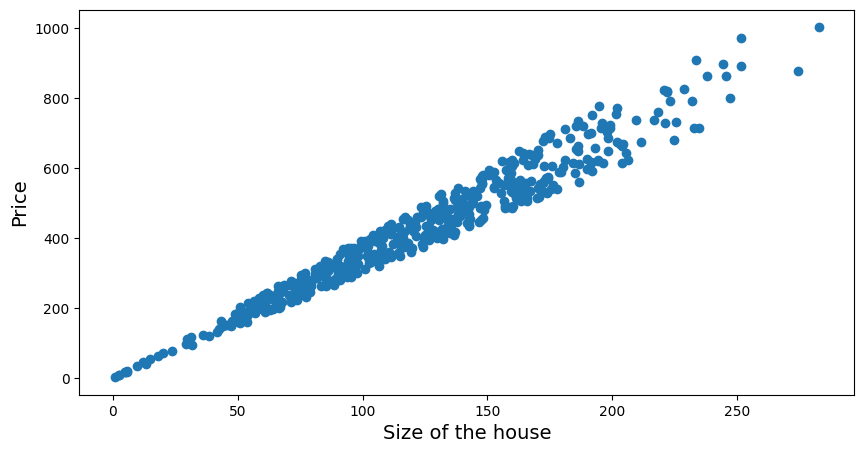

In [44]:
plot_2d_points(X, Y)

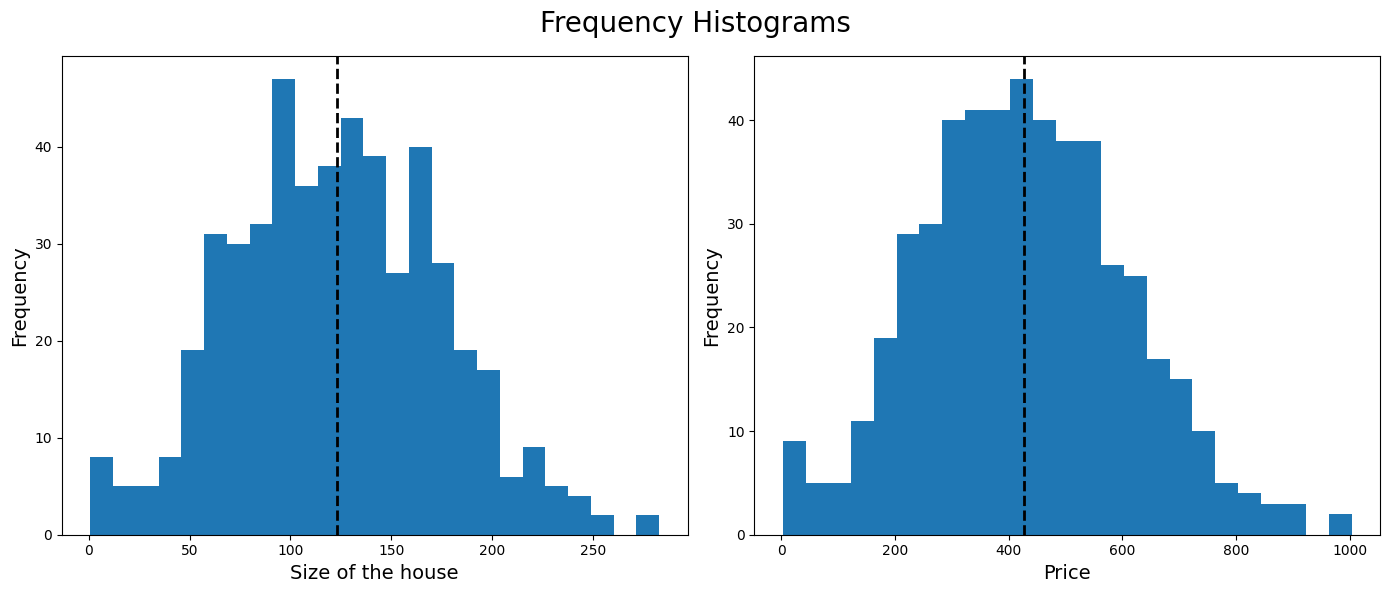

In [46]:
plot_distributions([X, Y], ["Size of the house", "Price"])

### Exercise 9.2
Perform the **Min-Max normalization** of the vector `X` and assign the normalized vector into a variable `X_norm`.

$$ X\_norm = \frac{(X - X_{min})}{(X_{max} - X_{min})} $$

#### NOTE: Exploit Numpy and broadcasting instead of lists or explicit for loops!

<details>
<summary><b>Hints</b></summary>
<ul><li>You should exploit <strong>broadcasting</strong>.</li></ul>
</details>

#### Expected output
```
Minimum value after norm: 0.00
Maximum value after norm: 1.00
Mean after norm: ~0.50 (with some randomness)
Standard deviation after norm: ~0.15 (with some randomness)
```

In [47]:
#### START CODE HERE ####
X_min = X.min()
X_max = X.max()
X_norm = (X - X_min) / (X_max-X_min)
#### END CODE HERE ####

print("Minimum value after norm: {:.2f}".format(X_norm.min()))
print("Maximum value after norm: {:.2f}".format(X_norm.max()))
print("Mean after norm: {:.2f}".format(X_norm.mean()))
print("Standard deviation after norm: {:.2f}".format(X_norm.std()))
print("First five elements of X_norm: ", X_norm[:5])

Minimum value after norm: 0.00
Maximum value after norm: 1.00
Mean after norm: 0.43
Standard deviation after norm: 0.18
First five elements of X_norm:  [0.48002225 0.30183097 0.21072151 0.4157858  0.25015181]


If you implemented the normalization correctly, the min and max values of `X_norm` must be 0 and 1, respectively.

Run the next cells to plot the normalized data.

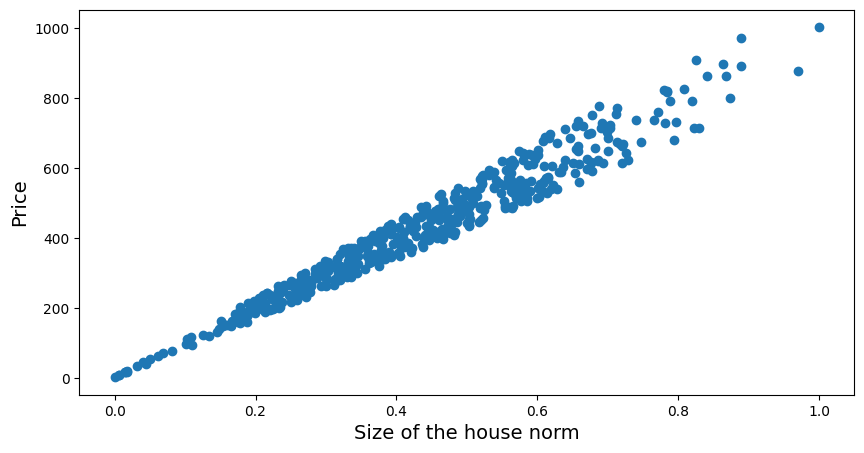

In [48]:
plot_2d_points(X_norm, Y, True)

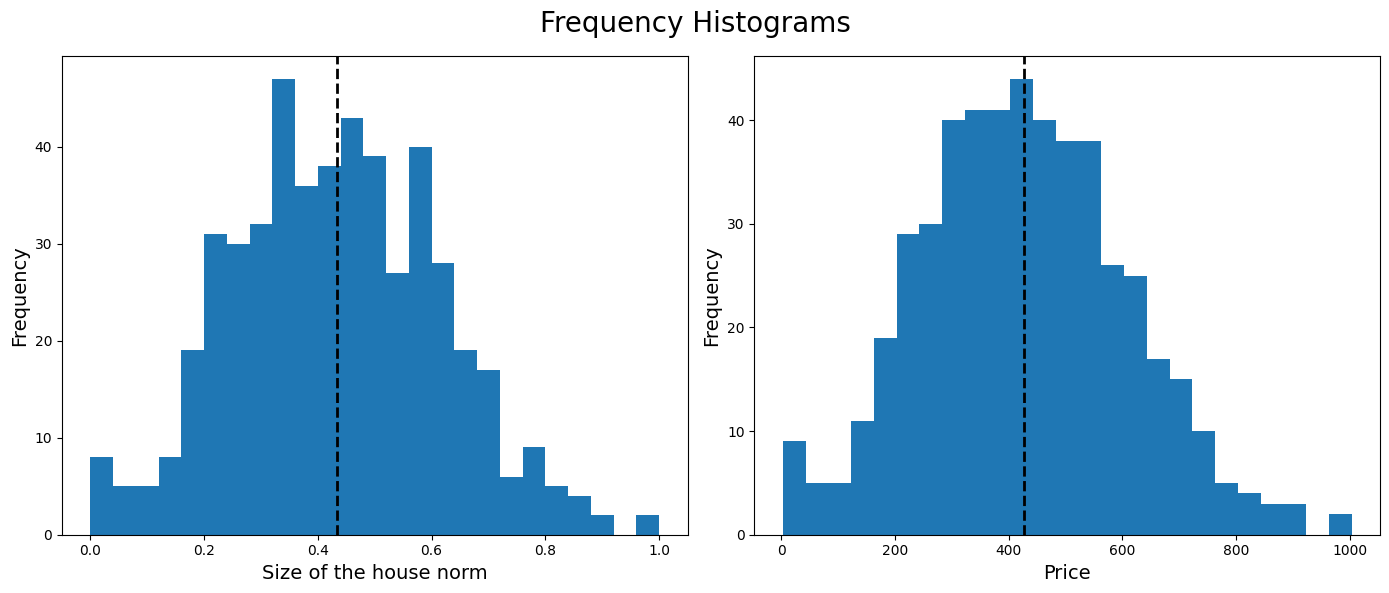

In [50]:
plot_distributions([X_norm, Y], ["Size of the house norm", "Price"])

After the Min-Max normalization, the values of `X` are rescaled in the range [0, 1]. The distribution is preserved.

Congratulations! You have correctly normalized a one-dimensional array using NumPy.

Now let's try a two-dimensional array.

### 9.3 Min-Max normalization of two-dimensional data

Now we move to a **2-dimensional case**. We create an artificial dataset `X` with 2 features: the **size of the house (m²)** (first column) and the **number of rooms** (second column). The target is still the **price** (in thousands of €).

Notice that the input features have a **different scale**. This can be **problematic** when training a learning algorithm.

#### Synthetic dataset generation: two-dimensional input features

Run the following cells to generate the 2-D dataset.

In [51]:
n_samples = 500

mu, sigma = 120, 50
X_size = np.random.normal(mu, sigma, (500,))
X_size = np.abs(X_size)

mu, sigma = 3, 2
X_rooms = np.random.normal(mu, sigma, n_samples)
X_rooms = X_rooms.astype(int)
X_rooms = X_rooms + np.min(X_rooms) * -1 + 1  # minimum number of rooms = 1

X = np.hstack((X_size.reshape(-1, 1), X_rooms.reshape(-1, 1)))

print("X Shape", X.shape)
print("X size of the house - Minimum value: {:.2f}".format(X[:, 0].min()))
print("X size of the house - Maximum value: {:.2f}".format(X[:, 0].max()))
print("X size of the house - mean: {:.2f}".format(X[:, 0].mean()))
print("X size of the house - standard deviation: {:.2f}".format(X[:, 0].std()))
print("First five elements of X size of the house: {}".format(X[:5, 0]))
print("X n rooms - Minimum value: {:.2f}".format(X[:, 1].min()))
print("X n rooms - Maximum value: {:.2f}".format(X[:, 1].max()))
print("X n rooms - mean: {:.2f}".format(X[:, 1].mean()))
print("X n rooms - standard deviation: {:.2f}".format(X[:, 1].std()))
print("First five elements of X n rooms: {}".format(X[:5, 1]))

X Shape (500, 2)
X size of the house - Minimum value: 1.71
X size of the house - Maximum value: 257.54
X size of the house - mean: 119.77
X size of the house - standard deviation: 48.56
First five elements of X size of the house: [182.0439786   84.86261117 233.28563452 125.81817257  35.7649653 ]
X n rooms - Minimum value: 1.00
X n rooms - Maximum value: 13.00
X n rooms - mean: 5.61
X n rooms - standard deviation: 1.92
First five elements of X n rooms: [7. 6. 5. 6. 3.]


In [52]:
price_per_mq = 3.5
increment_per_room = 0.05
error_size = np.random.random((500,)) - 0.5
error_rooms = (np.random.random((500,)) - 0.5) / 10
Y = X[:, 0] * (price_per_mq + error_size) + X[:, 1] * (increment_per_room + error_rooms)

print("Y Shape", Y.shape)
print("Y Minimum value: {:.2f}".format(Y.min()))
print("Y Maximum value: {:.2f}".format(Y.max()))
print("Y mean: {:.2f}".format(Y.mean()))
print("Y standard deviation: {:.2f}".format(Y.std()))
print("First five elements of Y: ", Y[:5])

Y Shape (500,)
Y Minimum value: 7.06
Y Maximum value: 910.50
Y mean: 418.84
Y standard deviation: 175.48
First five elements of Y:  [721.20542081 308.80110516 878.86244889 387.56305003 109.00312598]


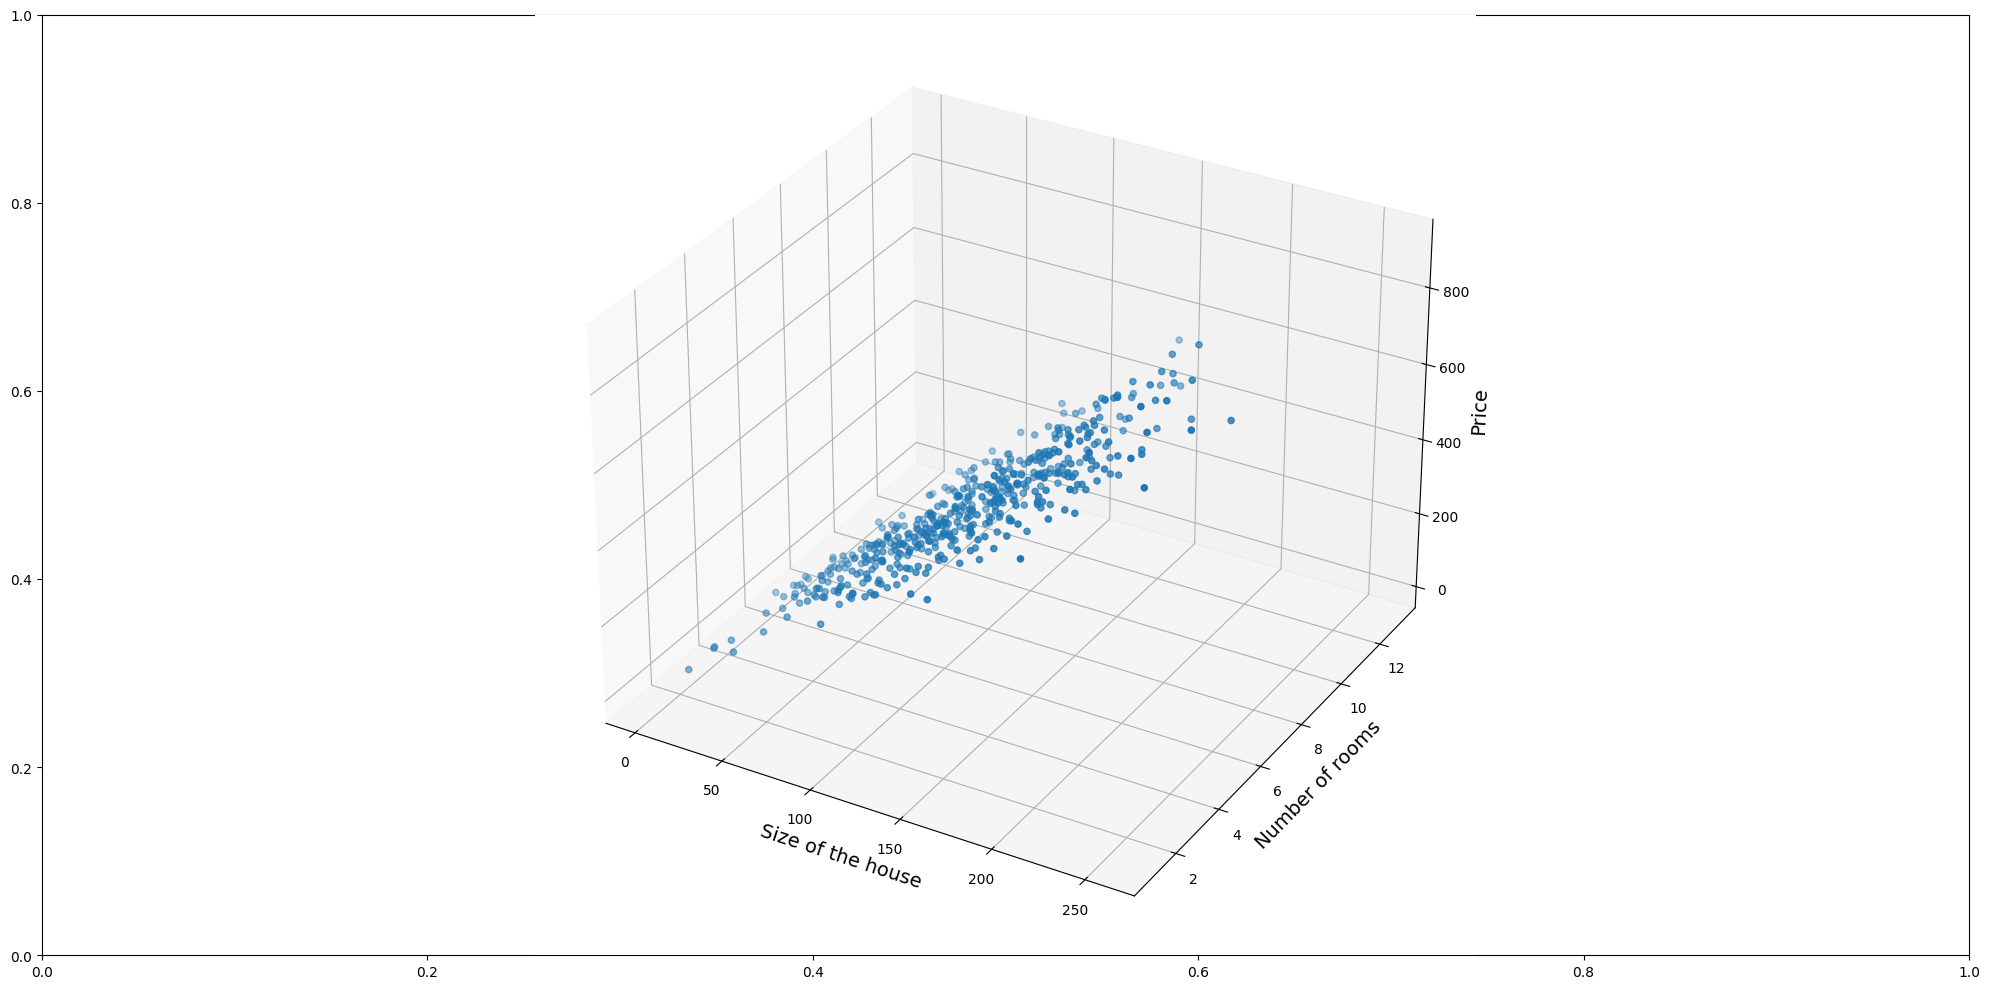

In [53]:
plot_3d_points(X, Y)

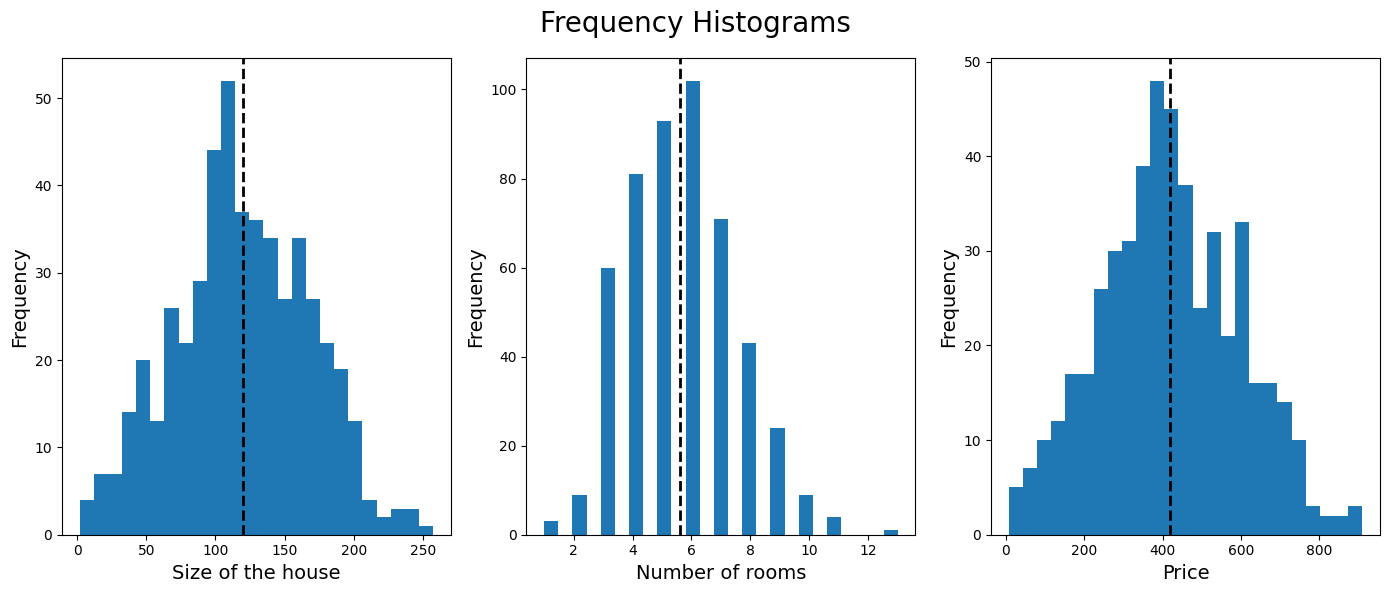

In [54]:
plot_distributions(
    [X[:, 0], X[:, 1], Y], ["Size of the house", "Number of rooms", "Price"]
)

### Exercise 9.4
Perform the **Min-Max normalization** of the 2-D array `X` and assign the result to `X_norm`. After the normalization, all the values of `X` (in **both** dimensions) must be in the range `[0, 1]`.

$$ X\_norm = \frac{(X - X_{min})}{(X_{max} - X_{min})} $$

*Important*: **this time, you should normalize each column separately** (i.e., the column with the size of the houses must be normalized with the min and max of the size of the houses, while the column with the number of rooms must be normalized with the min and max of the number of rooms).

#### NOTE: Exploit Numpy instead of lists or explicit for loops!

<details>
<summary><b>Hints</b></summary>
<ul>
<li>You should exploit <strong>broadcasting</strong>.</li>
<li>You should specify the <strong>axis</strong> parameter (e.g., <code>X.min(axis=0)</code> gives the min of each column).</li>
</ul>
</details>

In [56]:
#### START CODE HERE ####
X_min = X.min(axis=0)
X_max = X.max(axis=0)
X_norm = (X-X_min) / (X_max-X_min)
#### END CODE HERE ####

print("X_norm Shape", X_norm.shape)
print("X_norm size of the house - Minimum value: {:.2f}".format(X_norm[:, 0].min()))
print("X_norm size of the house - Maximum value: {:.2f}".format(X_norm[:, 0].max()))
print("X_norm size of the house - mean: {:.2f}".format(X_norm[:, 0].mean()))
print(
    "X_norm size of the house - standard deviation: {:.2f}".format(X_norm[:, 0].std())
)
print("First five elements of X_norm size of the house: {}".format(X_norm[:5, 0]))
print("X_norm n rooms - Minimum value: {:.2f}".format(X_norm[:, 1].min()))
print("X_norm n rooms - Maximum value: {:.2f}".format(X_norm[:, 1].max()))
print("X_norm n rooms - mean: {:.2f}".format(X_norm[:, 1].mean()))
print("X_norm n rooms - standard deviation: {:.2f}".format(X_norm[:, 1].std()))
print("First five elements of X_norm n rooms: {}".format(X_norm[:5, 1]))

X_norm Shape (500, 2)
X_norm size of the house - Minimum value: 0.00
X_norm size of the house - Maximum value: 1.00
X_norm size of the house - mean: 0.46
X_norm size of the house - standard deviation: 0.19
First five elements of X_norm size of the house: [0.70490967 0.32503873 0.90520748 0.48512937 0.13312161]
X_norm n rooms - Minimum value: 0.00
X_norm n rooms - Maximum value: 1.00
X_norm n rooms - mean: 0.38
X_norm n rooms - standard deviation: 0.16
First five elements of X_norm n rooms: [0.5        0.41666667 0.33333333 0.41666667 0.16666667]


If you implemented the normalization correctly, the min and max values of `X_norm` must be 0 and 1, respectively, for **both** dimensions.

Run the next cells to plot the normalized data.

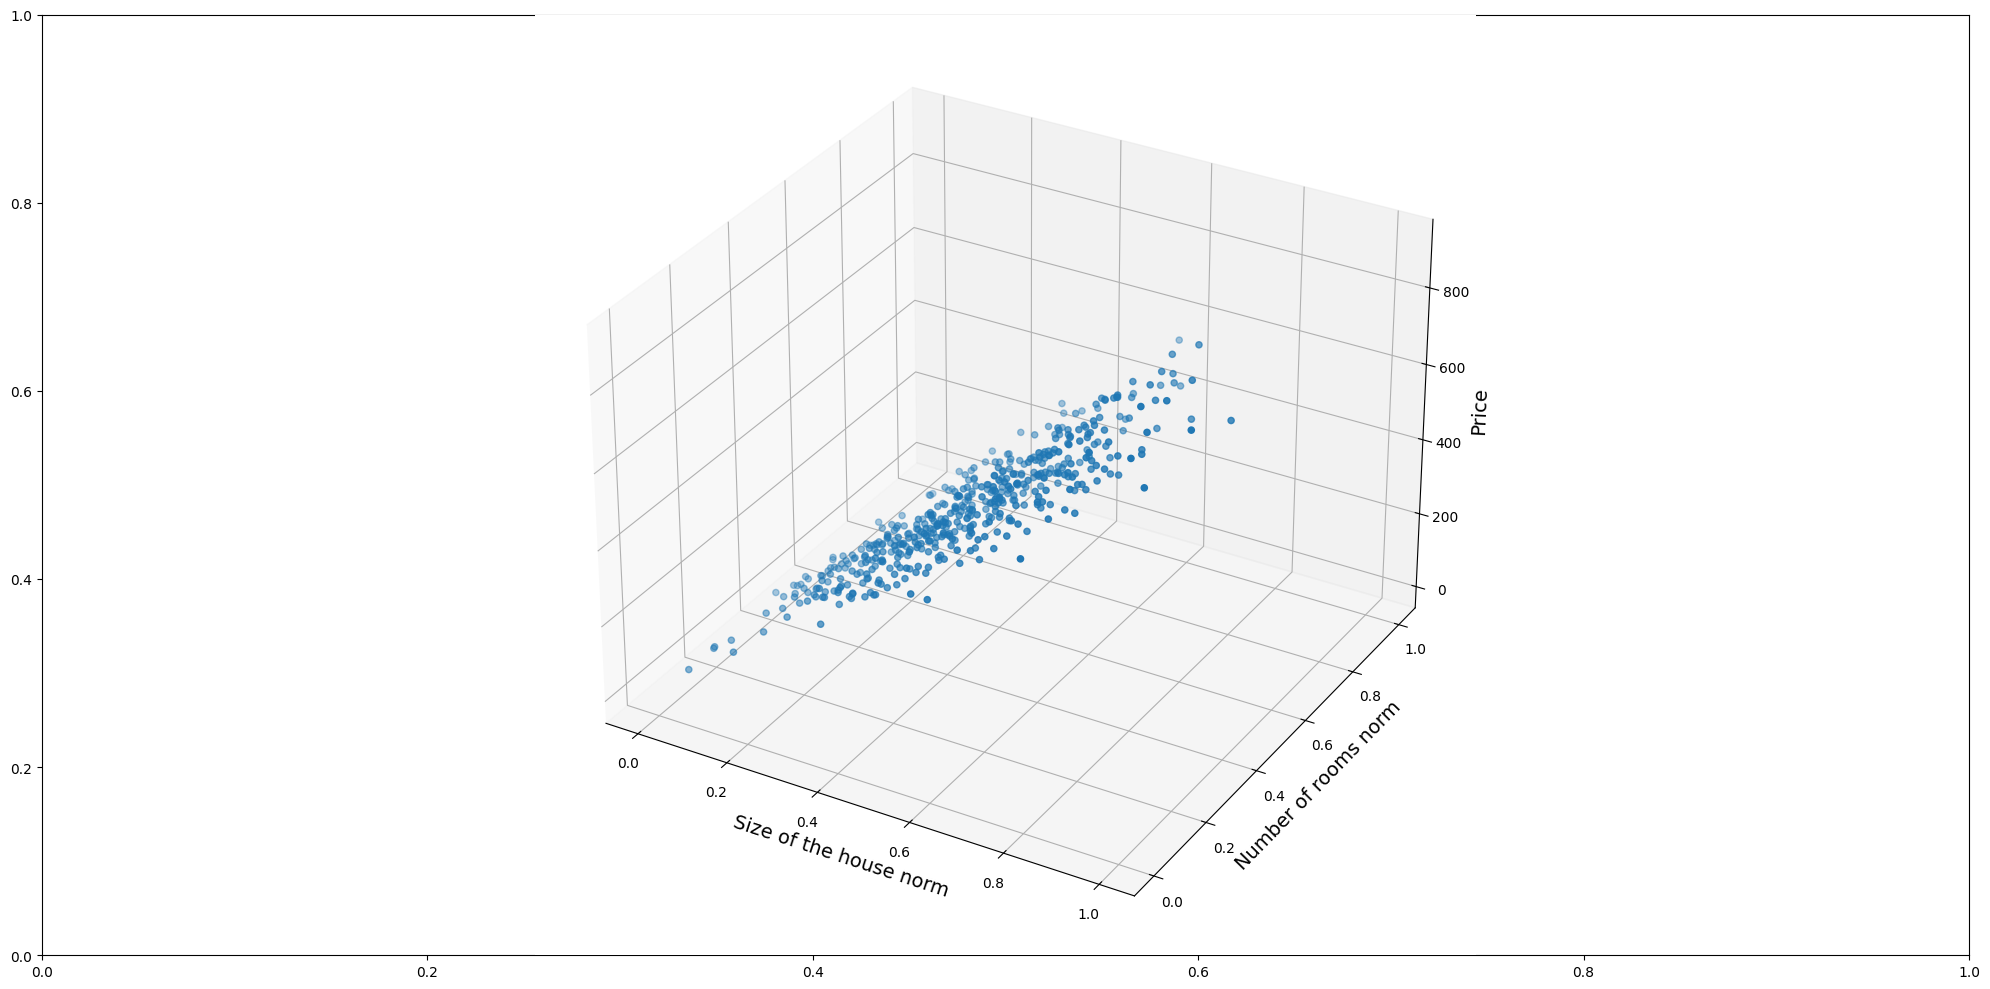

In [57]:
plot_3d_points(X_norm, Y, True)

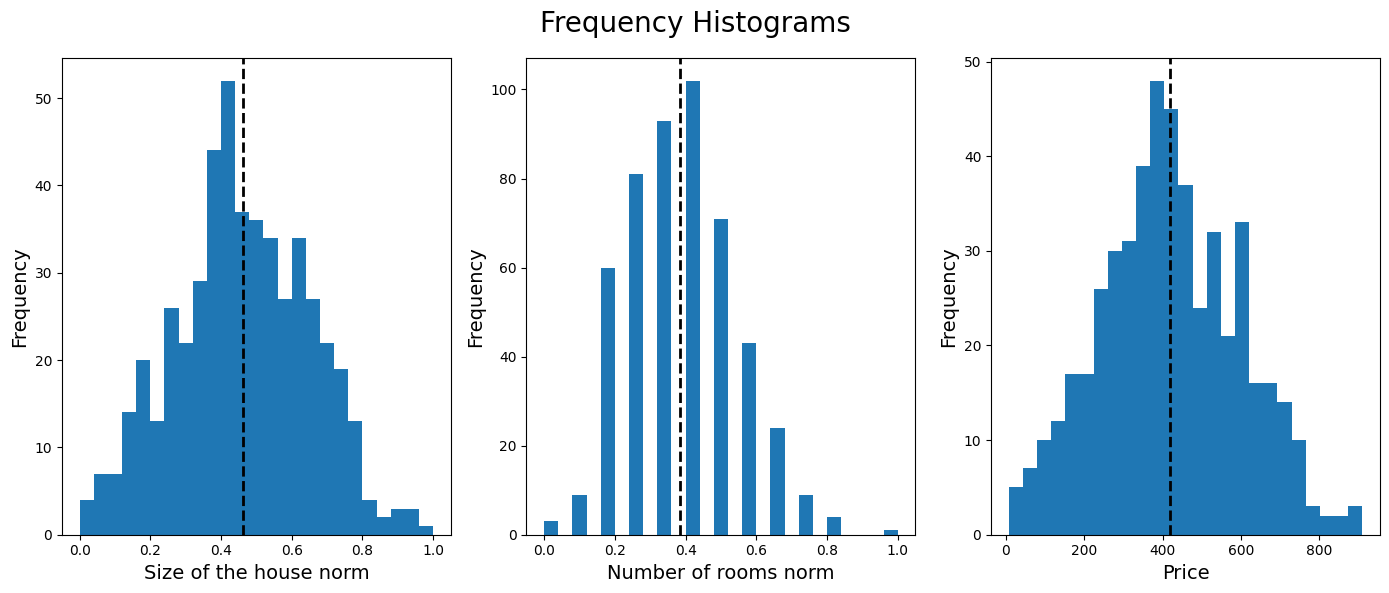

In [59]:
plot_distributions(
    [X_norm[:, 0], X_norm[:, 1], Y],
    ["Size of the house norm", "Number of rooms norm", "Price"],
)

After the Min-Max normalization, the values of `X` in both axes (size of the house and number of rooms) are rescaled in the range [0, 1]. The distributions are preserved.

Congratulations! You have correctly normalized a two-dimensional array of features using NumPy.